# 08 — Refined axes validity

Build atomic constructs and test coverage / coherence **before** seeing outcomes.
Prefer components when composites disagree (same rule as Stage 10 NB05).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh

ctx = nh.setup("08_refined_axes_validity")
cfg = ctx.cfg

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity


In [2]:
frame = nh.load_refined_frame(cfg, mode="strict")
manifest = pd.read_parquet(cfg.output_path("book_features_dir") / "refined_frame_manifest.parquet")
display(manifest.sort_values("nonzero_books", ascending=False).head(40))
ctx.save_table(manifest, "construct_coverage")

,column,nonzero_books,mean,median
47,RLR_emotional_vs_explicit,15996,4.5820,4.5789
23,RAX_nonexplicit_affection,15996,0.2267,0.2231
37,RAX_h1_emotional_side,15996,0.2801,0.2760
48,RLR_emotional_vs_material_security,15994,10.8841,10.8756
41,RAX_h3_emotional_side,15994,0.0562,0.0529
9,RAX_emotional_security,15994,0.0562,0.0529
8,RAX_emotional_reassurance,15993,0.0533,0.0500
0,RAX_arc_falling,15993,0.0756,0.0737
13,RAX_external_plot_conflict,15987,0.0274,0.0260
25,RAX_physical_protection,15978,0.0106,0.0101


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/construct_coverage.csv  (60 rows)


## Atomic construct distributions (no outcome conditioning)

In [3]:
atoms = [
    c
    for c in frame.columns
    if c.startswith("RAX_")
    and not c.startswith("RAX_h")
    and "begin" not in c
    and "end" not in c
]
usable = frame[frame.get("analysable", True) == True] if "analysable" in frame.columns else frame
summary = pd.DataFrame(
    {
        "construct": atoms,
        "pct_nonzero": [(usable[c] > 0).mean() * 100 for c in atoms],
        "mean": [usable[c].mean() for c in atoms],
        "median": [usable[c].median() for c in atoms],
        "p90": [usable[c].quantile(0.9) for c in atoms],
    }
).sort_values("mean", ascending=False)
display(summary.round(4))
ctx.save_table(summary, "atomic_construct_summary")

,construct,pct_nonzero,mean,median,p90
22,RAX_nonexplicit_affection,99.9812,0.2268,0.2231,0.2817
0,RAX_arc_falling,99.9625,0.0756,0.0737,0.0967
9,RAX_emotional_security,99.9687,0.0562,0.0529,0.0754
8,RAX_emotional_reassurance,99.9625,0.0533,0.0500,0.0723
13,RAX_external_plot_conflict,99.9250,0.0274,0.0260,0.0368
27,RAX_practical_care,99.6062,0.0264,0.0210,0.0520
33,RAX_sexual_tension,99.5187,0.0174,0.0151,0.0317
16,RAX_generic_confession_apology,99.8437,0.0136,0.0123,0.0222
34,RAX_status_display,99.8625,0.0108,0.0096,0.0182
24,RAX_physical_protection,99.8687,0.0106,0.0101,0.0153


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/atomic_construct_summary.csv  (35 rows)


## Inter-construct correlations

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/figures/construct_correlations.png


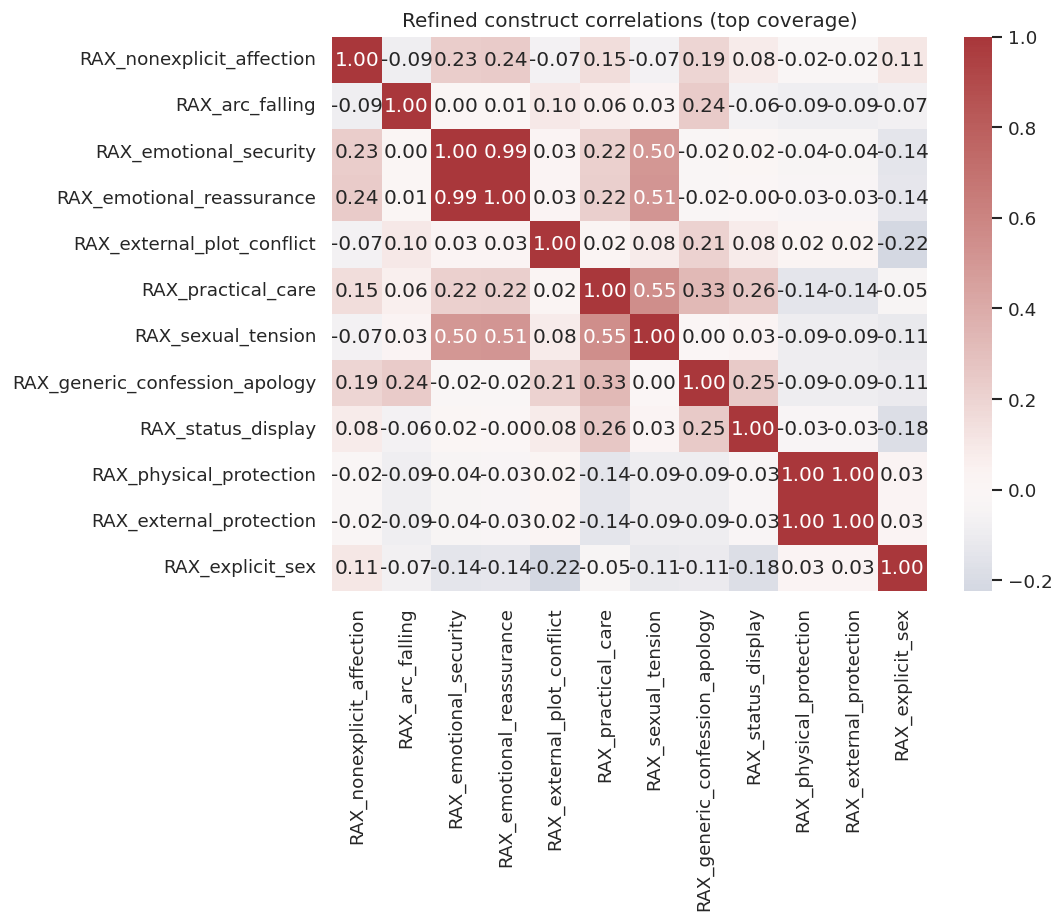

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/construct_correlations.csv  (12 rows)


In [4]:
top = summary.head(12)["construct"].tolist()
corr = usable[top].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Refined construct correlations (top coverage)")
ctx.save_figure(fig, "construct_correlations")
plt.show()
ctx.save_table(corr.reset_index(), "construct_correlations")

## Strict vs weighted agreement

In [5]:
strict = nh.load_refined_frame(cfg, "strict")
weighted = nh.load_refined_frame(cfg, "weighted")
common = [c for c in atoms if c in weighted.columns]
agree = []
for c in common:
    r = np.corrcoef(strict[c].fillna(0), weighted[c].fillna(0))[0, 1]
    agree.append({"construct": c, "corr_strict_weighted": float(r)})
agree_df = pd.DataFrame(agree).sort_values("corr_strict_weighted")
display(agree_df)
ctx.save_table(agree_df, "strict_vs_weighted_agreement")

/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,construct,corr_strict_weighted
22,RAX_nonexplicit_affection,0.9367
11,RAX_explicit_sex,0.9943
9,RAX_emotional_security,0.9967
8,RAX_emotional_reassurance,0.9967
14,RAX_external_protection,0.9975
24,RAX_physical_protection,0.9975
16,RAX_generic_confession_apology,0.9987
1,RAX_arc_rising,0.9996
21,RAX_mutual_commitment,1.0000
15,RAX_final_relational_payoff,1.0000


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/08_refined_axes_validity/tables/strict_vs_weighted_agreement.csv  (35 rows)


## Author concentration (top construct)

In [6]:
if "author_id" in usable.columns and top:
    c0 = top[0]
    by_auth = usable.groupby("author_id")[c0].mean().sort_values(ascending=False)
    print(f"Top construct {c0}: top author mean={by_auth.iloc[0]:.4f}, median author={by_auth.median():.4f}")
    print(f"Share of books from singleton authors: {(usable.groupby('author_id').size() == 1).mean():.1%}")

print("Validity checks complete — proceed to hypothesis tests in notebook 09.")

Top construct RAX_nonexplicit_affection: top author mean=0.8969, median author=0.2227
Share of books from singleton authors: 64.8%
Validity checks complete — proceed to hypothesis tests in notebook 09.
